# Batch export SECORE H10 IBI/RMSSD to NCDF

This notebook builds `h10_xarray` with `build_h10_ibi_rmssd_xarray_auto` and exports SECORE NCDF files for all dyads from the same list used in EEG batch export.

In [1]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# Add project root so src package imports work from scripts/
sys.path.insert(0, os.path.abspath('..'))

from src.secore_loader import build_h10_ibi_rmssd_xarray_auto
from src.secore_utils import export_h10_to_secore_ncdf, save_secore_QC_figures, sec_ms_str_to_float


In [ ]:
input_folder = "/Users/admin/Library/CloudStorage/GoogleDrive-j.zygierewicz@uw.edu.pl/.shortcut-targets-by-id/1N4ySQ5GO6UE8fY2jnRkRUjBFm4XHrBRv/SYNCC-IN/WP4          - Joint study/UniWAW Data collection/UNIWAW_RAW_DATA"
export_folder = "/Users/admin/Library/CloudStorage/GoogleDrive-j.zygierewicz@uw.edu.pl/.shortcut-targets-by-id/1N4ySQ5GO6UE8fY2jnRkRUjBFm4XHrBRv/SYNCC-IN/WP4          - Joint study/UniWAW Data collection/UNIWAW_EEG_exported"
input_synchronization_data = os.path.join(input_folder, "timings_secore_hrv.csv")
# Hardcoded H10 device IDs (same as secore_raw_import_demo.ipynb)
DEV_CG = "A839C92B"  # Caregiver H10 device ID
DEV_CH = "A83E1E24"  # Child H10 device ID

# Build settings
plot_flag = True
fs_ibi = 8
window_size_rmssd_s = 30
decimate_factor_loader = 8
decimate_factor_align = 16
selected_time = (0, 220)

In [3]:
# Informacja od Weroniki:
# Diady które na pewno można wykluczyć z takiego automatycznego eksportu, bo nie miały eeg lub h10 wg Warsaw IDs, to:
# 6,7,8,10,11,33,46,47,79,90,93,96 (na czerwono nie mają obu modalności)
# Dodatkowo diada 3 ma h10 tylko od dziecka, a 92 ma eeg zapisane w dwóch plikach (wywaliło się nagrywanie w trakcie).
not_complete_dyads = ['W_003','W_006','W_007','W_008','W_010','W_011',
                      'W_033','W_046','W_047','W_079','W_090','W_093','W_096']
                
# Same dyad list as in export_EEG_UNIWAW_dyades_to_ncdf.ipynb
dyades_to_export = [
    'W_000', 'W_016',          'W_049', 'W_086',
    'W_001', 'W_017', 'W_034', 'W_053', 'W_087',
    'W_002', 'W_018', 'W_035', 'W_057', 'W_088',
             'W_019', 'W_036', 'W_064', 
    'W_004', 'W_020', 'W_037', 'W_071', 'W_091',
    'W_005', 'W_021', 'W_038', 'W_072', 'W_092',
             'W_022', 'W_039', 'W_073', 
    'W_024', 'W_040', 'W_074', 'W_094',
             'W_025', 'W_041', 'W_075', 
    'W_009', 'W_026', 'W_042', 'W_076', 'W_097',
             'W_027', 'W_043', 'W_077', 'W_104',
             'W_028', 'W_044', 'W_078', 'W_112',
    'W_012', 'W_029', 'W_045',        
    'W_013', 'W_030',          'W_081',
    'W_014', 'W_031',          'W_084',
    'W_015', 'W_032', 'W_048', 'W_085'
]

metadata_file = os.path.join(input_folder, "meta_data.csv")
metadata_df = pd.read_csv(metadata_file, sep=';')
synchronization_df = pd.read_csv(input_synchronization_data, sep=',')

dyades_to_export = [dyad for dyad in dyades_to_export if dyad in metadata_df['ID'].values]
dyades_to_export = sorted(dyades_to_export)
print(f"Exporting {len(dyades_to_export)} dyads: {dyades_to_export}")

Exporting 62 dyads: ['W_000', 'W_001', 'W_002', 'W_004', 'W_005', 'W_009', 'W_012', 'W_013', 'W_014', 'W_015', 'W_016', 'W_017', 'W_018', 'W_019', 'W_020', 'W_021', 'W_022', 'W_024', 'W_025', 'W_026', 'W_027', 'W_028', 'W_029', 'W_030', 'W_031', 'W_032', 'W_034', 'W_035', 'W_036', 'W_037', 'W_038', 'W_039', 'W_040', 'W_041', 'W_042', 'W_043', 'W_044', 'W_045', 'W_048', 'W_049', 'W_053', 'W_057', 'W_064', 'W_071', 'W_072', 'W_073', 'W_074', 'W_075', 'W_076', 'W_077', 'W_078', 'W_081', 'W_084', 'W_085', 'W_086', 'W_087', 'W_088', 'W_091', 'W_092', 'W_094', 'W_097', 'W_104']


Skipping W_000: dyad synchronization is yet unavailable
Building/exporting W_001...
Auto-detected latest recording for W_1: None None, CH=A83E1E24, CG=A839C92B
Detected events: {'Brave': {'name': 'Brave', 'start': 131.8779296875, 'duration': 60.1484375}, 'Peppa': {'name': 'Peppa', 'start': 272.556640625, 'duration': 60.46484375}, 'Incredibles': {'name': 'Incredibles', 'start': 202.259765625, 'duration': 60.046875}}
Applying iir filters to EEG data.
Reseting the EEG time to the start of Brave
No ET_event found, using EEG_events data only.
Events column created based on EEG_events and ET_event columns.
Event structure created based on events column.

Event Name                     Start (s)       Duration (s)   
Brave                          0.00            60.14          
Incredibles                    70.39           60.04          
Peppa                          140.68          60.45          

Computed lags (in seconds) to ECG: CG=4115.375, CH=4078.5


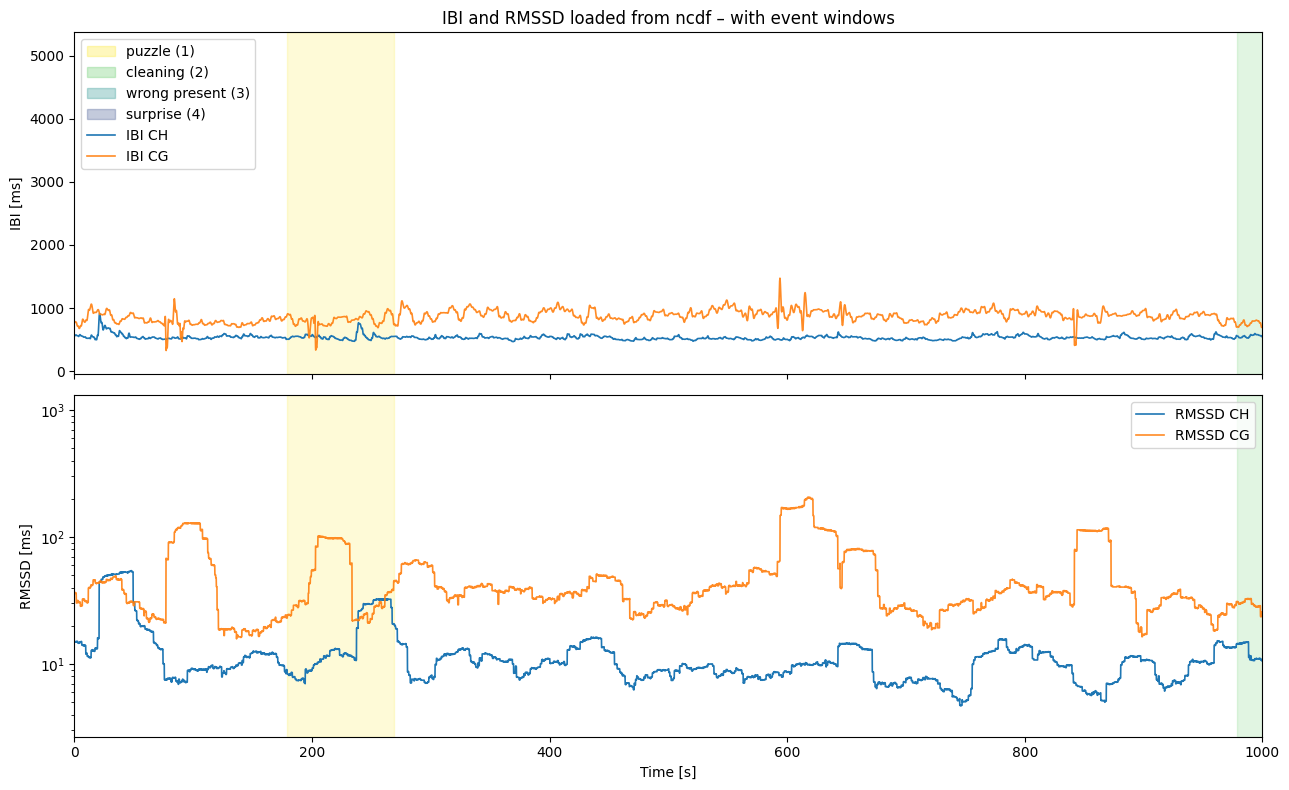

Done: W_001 (4 files)
Building/exporting W_002...
Auto-detected latest recording for W_2: None None, CH=A83E1E24, CG=A839C92B
Detected events: {'Brave': {'name': 'Brave', 'start': 375.8115234375, 'duration': 59.2978515625}, 'Peppa': {'name': 'Peppa', 'start': 445.3427734375, 'duration': 59.6298828125}, 'Incredibles': {'name': 'Incredibles', 'start': 515.189453125, 'duration': 59.212890625}, 'Talk_1': {'name': 'Talk_1', 'start': 752.697265625, 'duration': 181.0380859375}, 'Talk_2': {'name': 'Talk_2', 'start': 1078.125, 'duration': 181.0712890625}}
Applying iir filters to EEG data.
Reseting the EEG time to the start of Brave
No ET_event found, using EEG_events data only.
Events column created based on EEG_events and ET_event columns.
Event structure created based on events column.

Event Name                     Start (s)       Duration (s)   
Brave                          0.00            59.30          
Peppa                          69.53           59.62          
Incredibles         

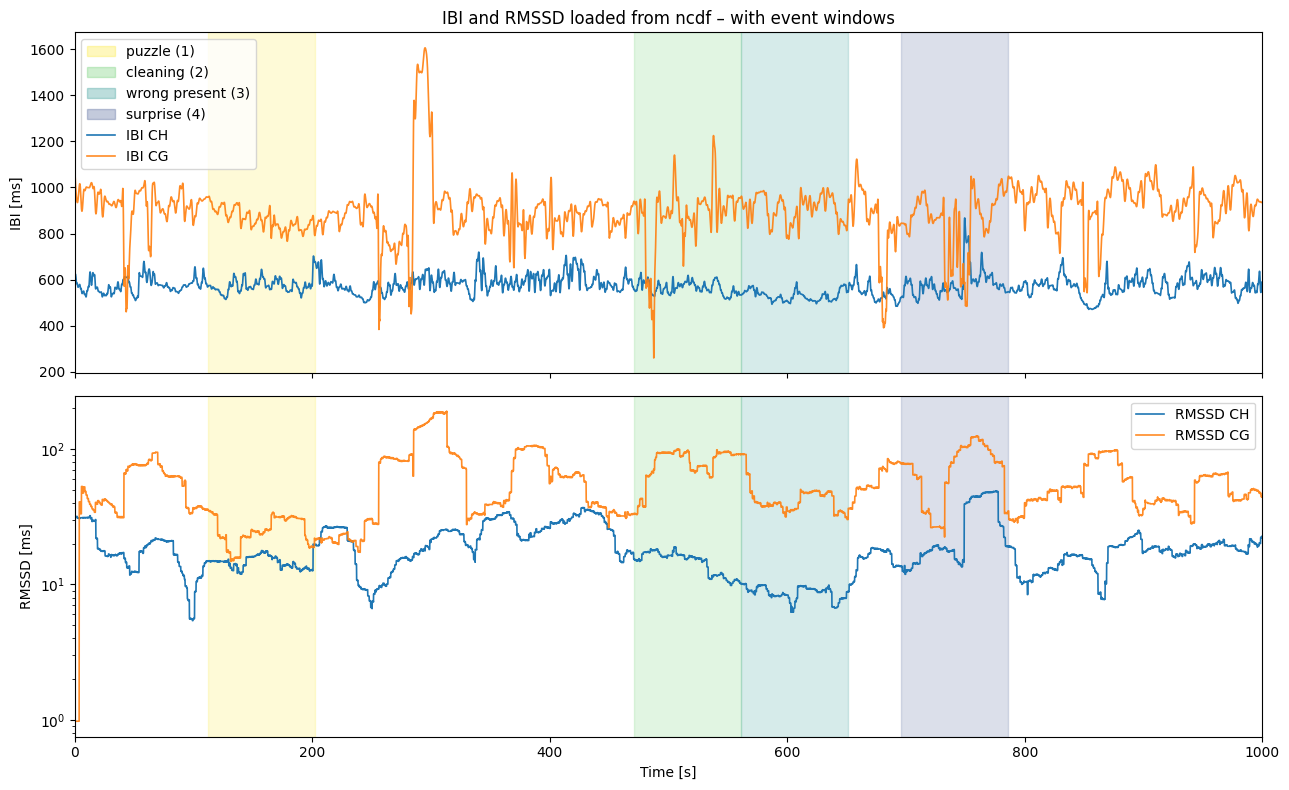

Done: W_002 (4 files)
Building/exporting W_004...
Auto-detected latest recording for W_4: None None, CH=A83E1E24, CG=A839C92B
Detected events: {'Brave': {'name': 'Brave', 'start': 263.7421875, 'duration': 59.3310546875}, 'Peppa': {'name': 'Peppa', 'start': 333.306640625, 'duration': 59.6298828125}, 'Incredibles': {'name': 'Incredibles', 'start': 403.169921875, 'duration': 59.212890625}, 'Talk_1': {'name': 'Talk_1', 'start': 603.2099609375, 'duration': 181.0556640625}, 'Talk_2': {'name': 'Talk_2', 'start': 898.244140625, 'duration': 181.0546875}}
Applying iir filters to EEG data.
Reseting the EEG time to the start of Brave
No ET_event found, using EEG_events data only.
Events column created based on EEG_events and ET_event columns.
Event structure created based on events column.

Event Name                     Start (s)       Duration (s)   
Brave                          0.00            59.33          
Peppa                          69.57           59.62          
Incredibles          

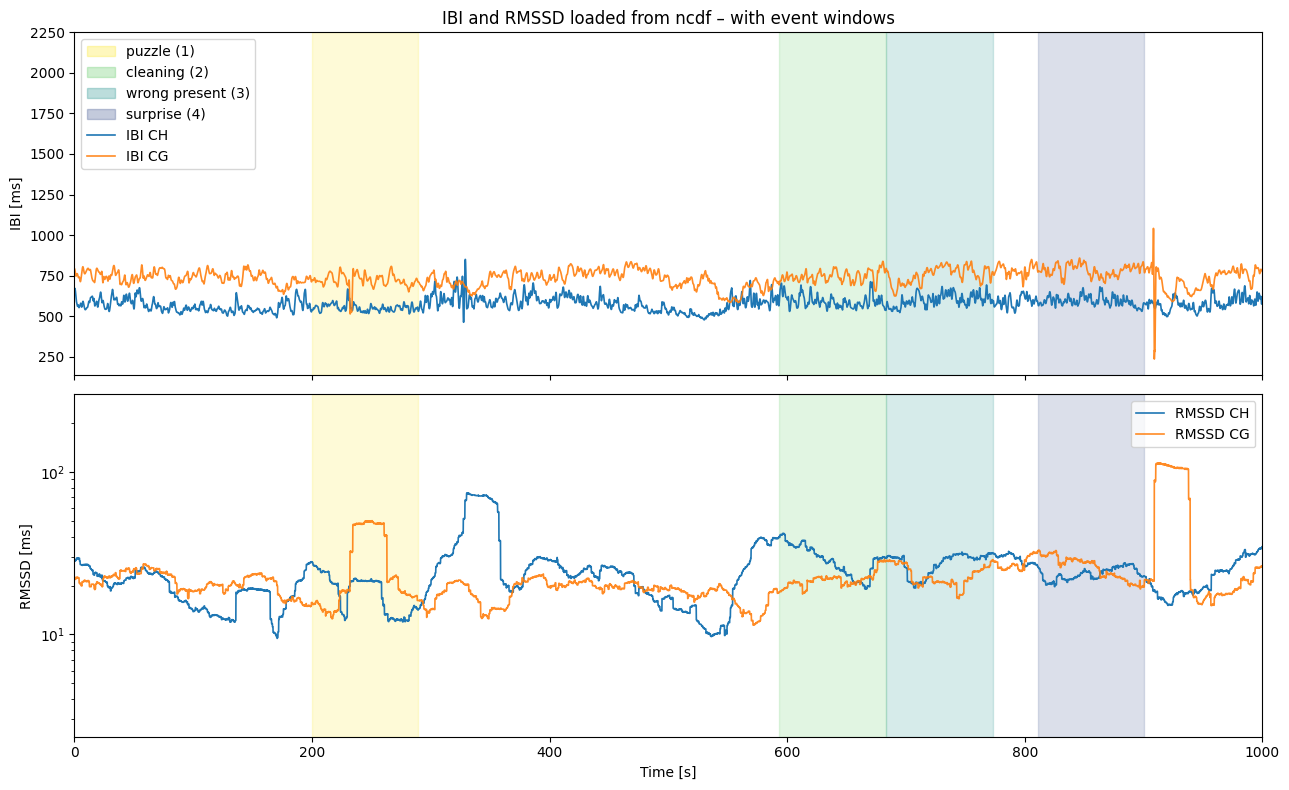

Done: W_004 (4 files)
Building/exporting W_005...
Auto-detected latest recording for W_5: None None, CH=A83E1E24, CG=A839C92B
Detected events: {'Brave': {'name': 'Brave', 'start': 520.365234375, 'duration': 59.3125}, 'Peppa': {'name': 'Peppa', 'start': 450.466796875, 'duration': 59.615234375}, 'Incredibles': {'name': 'Incredibles', 'start': 589.9111328125, 'duration': 59.212890625}, 'Talk_1': {'name': 'Talk_1', 'start': 786.181640625, 'duration': 181.0546875}, 'Talk_2': {'name': 'Talk_2', 'start': 1055.79296875, 'duration': 181.0546875}}
Applying iir filters to EEG data.
Reseting the EEG time to the start of Peppa
No ET_event found, using EEG_events data only.
Events column created based on EEG_events and ET_event columns.
Event structure created based on events column.

Event Name                     Start (s)       Duration (s)   
Peppa                          0.00            59.61          
Brave                          69.90           59.30          
Incredibles                  

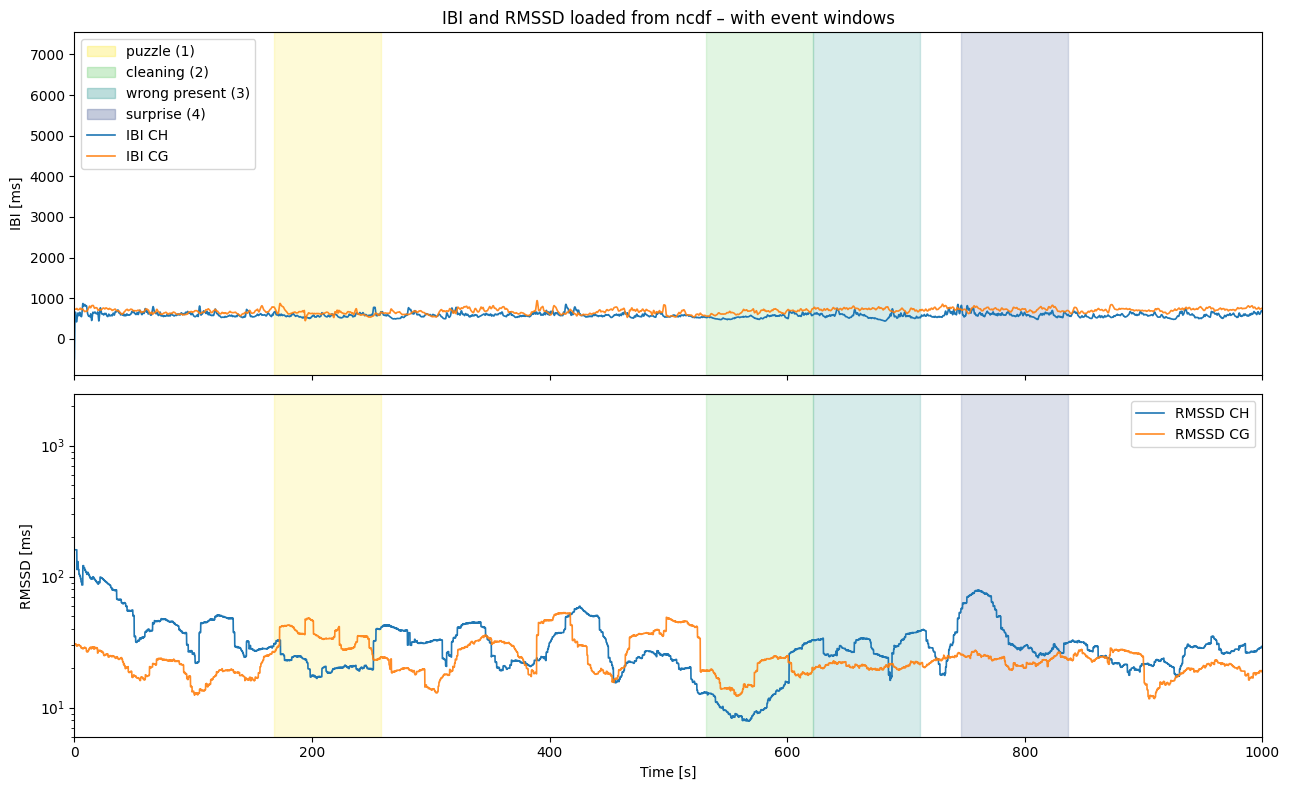

Done: W_005 (4 files)
Building/exporting W_009...
Auto-detected latest recording for W_9: None None, CH=A83E1E24, CG=A839C92B
Detected events: {'Brave': {'name': 'Brave', 'start': 308.4150390625, 'duration': 59.298828125}, 'Peppa': {'name': 'Peppa', 'start': 447.4443359375, 'duration': 59.630859375}, 'Incredibles': {'name': 'Incredibles', 'start': 377.9462890625, 'duration': 59.21484375}, 'Talk_1': {'name': 'Talk_1', 'start': 633.20703125, 'duration': 181.0732421875}, 'Talk_2': {'name': 'Talk_2', 'start': 899.216796875, 'duration': 181.0400390625}}
Applying iir filters to EEG data.
Reseting the EEG time to the start of Brave
No ET_event found, using EEG_events data only.
Events column created based on EEG_events and ET_event columns.
Event structure created based on events column.

Event Name                     Start (s)       Duration (s)   
Brave                          0.01            59.29          
Incredibles                    69.54           59.20          
Peppa             

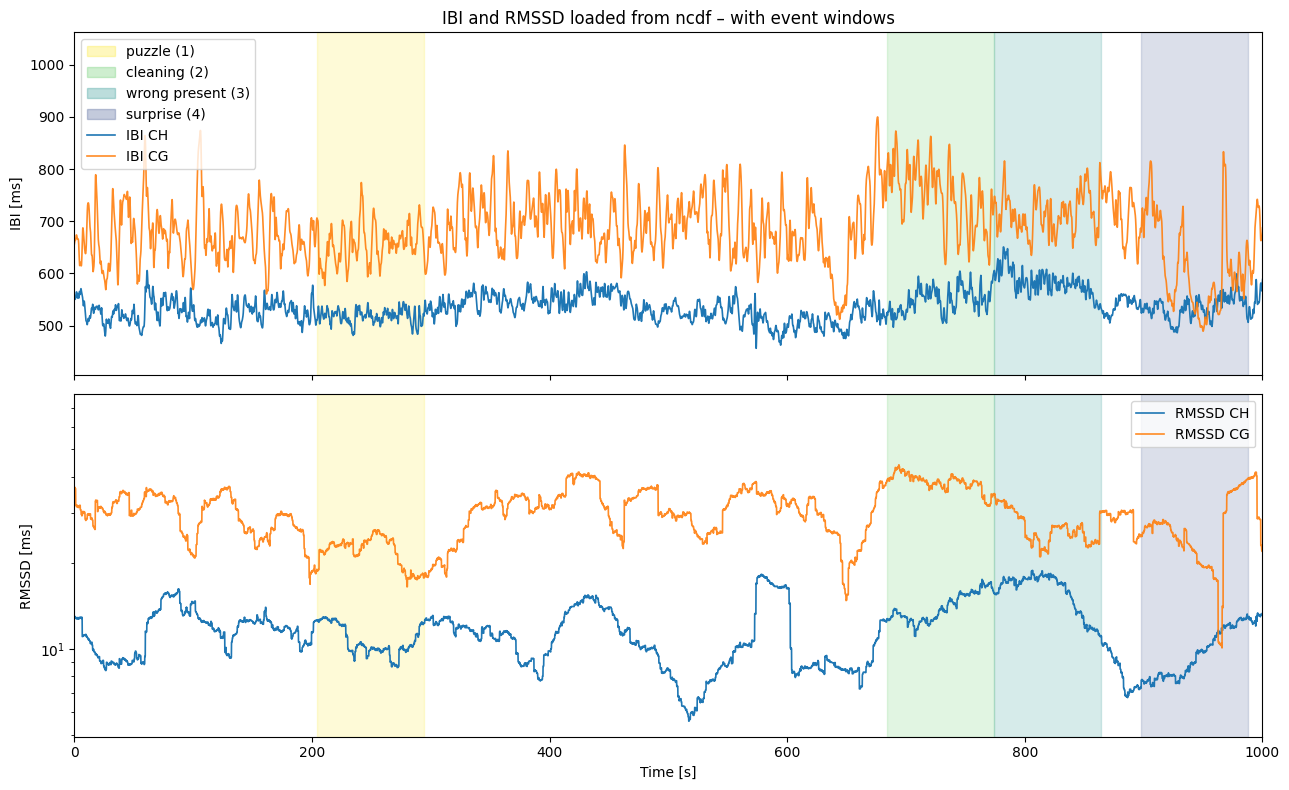

Done: W_009 (4 files)
Building/exporting W_012...
Auto-detected latest recording for W_12: None None, CH=A83E1E24, CG=A839C92B
Detected events: {'Brave': {'name': 'Brave', 'start': 294.3798828125, 'duration': 106.6591796875}}
Applying iir filters to EEG data.
Reseting the EEG time to the start of Brave


KeyboardInterrupt: 

In [4]:
failed_dyads = []
saved_files_all = []

for dyad in dyades_to_export:
    sync_row = synchronization_df.loc[synchronization_df['id'] == dyad]

    if sync_row.empty:
        print(f"Skipping {dyad}: dyad synchronization is yet unavailable")
        continue

    check_value = pd.to_numeric(sync_row['checked'], errors='coerce').iat[0]
    if check_value != 1:
        print(f"Skipping {dyad}: dyad synchronization is yet unavailable")
        continue

    video_timings = {
        "T1": float(sec_ms_str_to_float(sync_row['T1'].iat[0])),
        "T2": float(sec_ms_str_to_float(sync_row['T2'].iat[0])),
        "T3": float(sec_ms_str_to_float(sync_row['T3'].iat[0])),
        "T4": float(sec_ms_str_to_float(sync_row['T4'].iat[0])),
    }
    try:
        print(f"Building/exporting {dyad}...")

        dyad_nr = int(dyad.split('_')[1])
        synch_time = video_timings["T1"]
        h10_xarray = build_h10_ibi_rmssd_xarray_auto(
            dyad_nr=dyad_nr,
            video_timings=video_timings,
            data_base_path=input_folder,
            fs_ibi=fs_ibi,
            window_size_rmssd_s=window_size_rmssd_s,
            decimate_factor_loader=decimate_factor_loader,
            decimate_factor_align=decimate_factor_align,
            selected_time=selected_time,
            plot=plot_flag,
            save_dir=str(Path(export_folder) / "SECORE_FIGS"),
            preferred_dev_ch=DEV_CH,
            preferred_dev_cg=DEV_CG,
        )

        saved_files = export_h10_to_secore_ncdf(
            h10_xarray=h10_xarray,
            dyad_id=dyad,
            export_root=export_folder,
        )
        saved_files_all.extend(saved_files)
        save_secore_QC_figures(dyad_id=dyad, export_root=export_folder)
        print(f"Done: {dyad} ({len(saved_files)} files)")
    except Exception as e:
        failed_dyads.append((dyad, str(e)))
        print(f"Failed: {dyad} -> {e}")

print(
    f"Finished. Success: {len(dyades_to_export) - len(failed_dyads)}, "
    f"Failed: {len(failed_dyads)}, Exported files: {len(saved_files_all)}"
)

if failed_dyads:
    print("Failed dyads:")
    for dyad, err in failed_dyads:
        print(f"  - {dyad}: {err}")


In [ ]:
# Preview first saved files
for p in saved_files_all[:10]:
    print(p)